Installing the dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay ,accuracy_score

Data collection and preprocessing

In [ ]:
df = pd.read_csv("/content/data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.shape

(1888, 14)

check for missing values


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


check the distribution of the target


In [ ]:
df['target'].value_counts()

,count
target,
1,977
0,911


some statistical measures

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.135593,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.103852,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


check males vs females

In [ ]:
df["sex"].value_counts()

,count
sex,
1,1300
0,588


compare the target column with sex column

In [ ]:
pd.crosstab(index=df['sex'],columns=df['target'])

target,0,1
sex,,
0,198,390
1,713,587


Text(0, 0.5, 'Amount')

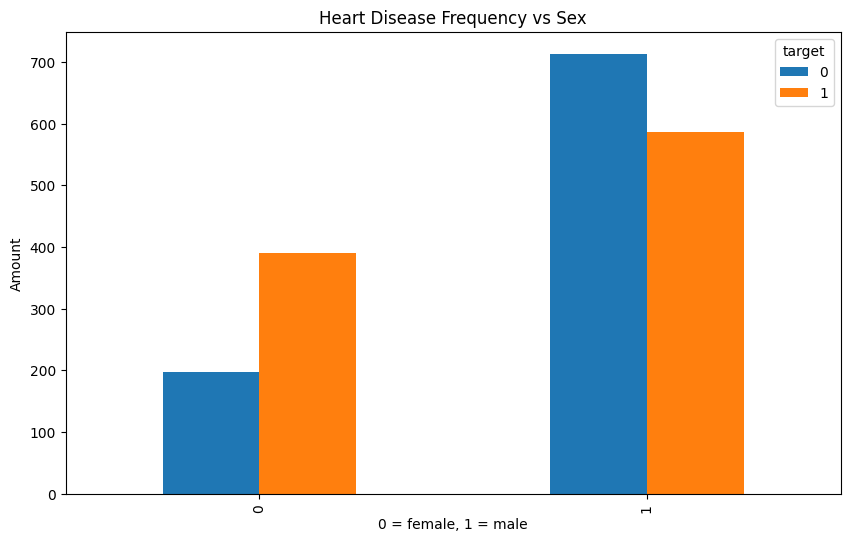

In [ ]:
pd.crosstab(df['sex'],df['target']).plot(kind="bar", figsize=(10,6));
plt.title("Heart Disease Frequency vs Sex")
plt.xlabel("0 = female, 1 = male")
plt.ylabel("Amount")

comparing heart desease and chest pain

In [ ]:
pd.crosstab(df['cp'],df['target'])


target,0,1
cp,,
0,581,205
1,90,223
2,162,374
3,78,175


Text(0, 0.5, 'Frequency')

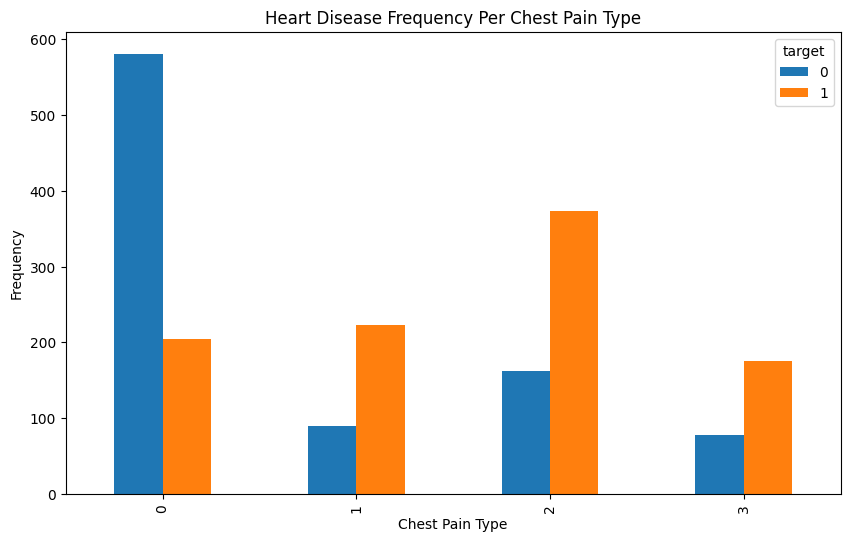

In [ ]:
pd.crosstab(df['cp'], df['target']).plot(kind="bar", figsize=(10,6),)
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")

RQ : atypical angina (value 1) states it's not related to the heartbut seems to have a higher ratio of participants with heart disease than not. and it seems that even some medical professionals are confused by the term.

correlation between independant features


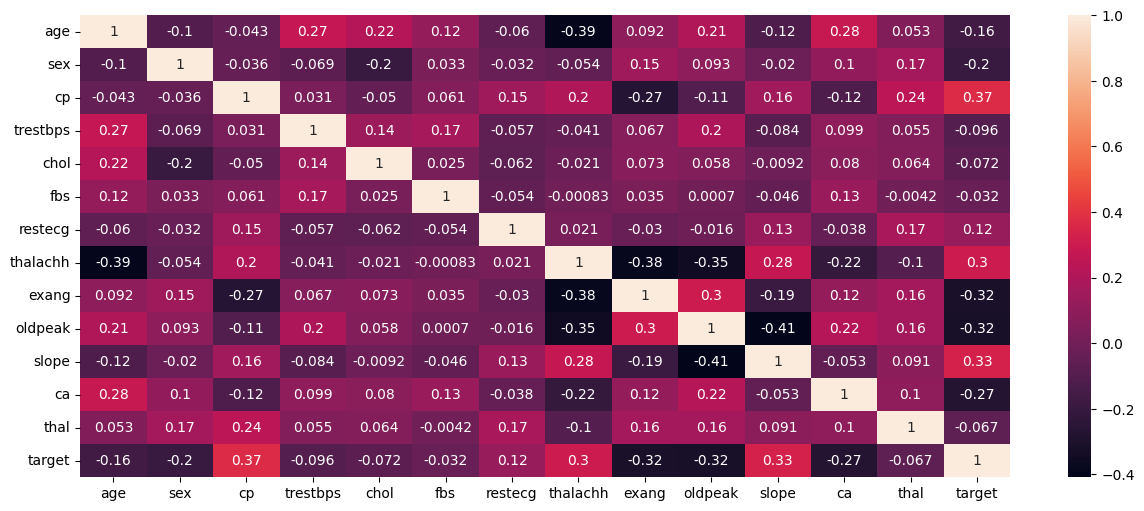

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(15,6))
sns.heatmap(corr_matrix,annot=True,);

this shows us that target is correlated with : cp-> slope->thalachh

and negatively correlated with (exang,oldpeak)->ca->sex

splitting features and the target

In [ ]:
X=df.drop(columns='target',axis=1)
y=df['target']

splitting the data into training data and test data

In [ ]:
random_seed=42
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
len(X_train),len(X_test)

(1510, 378)

training models


In [ ]:
models = {"KNN": KNeighborsClassifier(),"Logistic Regression": LogisticRegression(max_iter=5500),"Random Forest": RandomForestClassifier()}


In [ ]:
def fit_and_score(models, X_train, X_test, y_train, y_test):
  random_seed=42
  model_scores={}
  for name,model in models.items():
    model.fit(X_train,y_train)
    model_scores[name]=model.score(X_test,y_test)
  return model_scores

randfmodel=RandomForestClassifier().fit(X_train,y_train)

In [ ]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)
model_scores

{'KNN': 0.8095238095238095,
 'Logistic Regression': 0.7248677248677249,
 'Random Forest': 0.955026455026455}

let's hope its not an overfitting problem(we will know afterwards)

In [ ]:
X_train_prediction=randfmodel.predict(X_train)
training_accuracy=accuracy_score(X_train_prediction,y_train)

In [ ]:
print(training_accuracy)

1.0


although it's 1.0 on training data but still not an overfitting yet

tuning the KNeighborsClassifier

In [ ]:

train_scores = []

test_scores = []

neighbors = range(1, 21)
knn = KNeighborsClassifier()
for i in neighbors:
    knn.set_params(n_neighbors = i)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))

    test_scores.append(knn.score(X_test, y_test))

In [ ]:
train_scores

[1.0,
 0.9390728476821192,
 0.8629139072847682,
 0.8589403973509934,
 0.8576158940397351,
 0.8456953642384106,
 0.8364238410596027,
 0.7960264900662252,
 0.7649006622516556,
 0.7324503311258278,
 0.7079470198675497,
 0.714569536423841,
 0.6927152317880795,
 0.6827814569536423,
 0.6913907284768211,
 0.6966887417218544,
 0.7086092715231788,
 0.714569536423841,
 0.7105960264900663,
 0.7059602649006622]

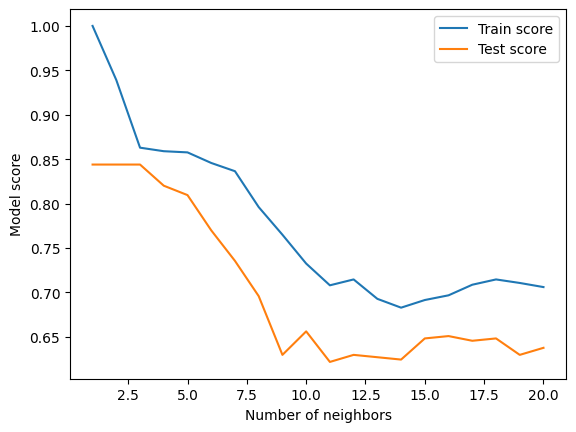

In [ ]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()


Looking at the graph, n_neighbors = 3 seems best.

tuning the other ones with RandomizedSearchCV

In [ ]:
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

In [ ]:
np.random.seed(42)

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(1.623776739188721)}

In [ ]:
rs_log_reg.score(X_test, y_test)

0.7248677248677249

That seems on par with the result we got before without any hyperparameter tuning....let's see teh what will the random forest do

In [ ]:

np.random.seed(42)
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)
rs_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
rs_rf.best_params_

{'n_estimators': np.int64(510),
 'min_samples_split': np.int64(14),
 'min_samples_leaf': np.int64(1),
 'max_depth': None}

In [ ]:
rs_rf.score(X_test, y_test)

0.955026455026455

this also is on par with the previous score...and it doesnt seem as an ovrefitting problem

 Tuning the models with GridSearchCV

In [ ]:
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
gs_log_reg.best_params_

{'C': np.float64(1.623776739188721), 'solver': 'liblinear'}

In [ ]:
gs_log_reg.score(X_test, y_test)

0.7248677248677249

In [ ]:
rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid=rf_grid,
    cv=5,
    verbose=True
)

gs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             verbose=True)

In [ ]:
gs_rf.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [ ]:
gs_rf.score(X_test, y_test)


0.9629629629629629

it is finally confirmed that the model is not overfitting

building a predective system

In [ ]:
input_data = (56,1,1,120,240,0,1,169,0,0,0,0,2)
input_data_array = np.array(input_data)
input_data_reshaped=input_data_array .reshape(1,-1)
prediction=rs_rf.predict(input_data_reshaped)
print(prediction)
if prediction[0]==1:
  print("the person has heart desease")
else :
  print("the person doesn't have heart desease")

[1]
the person has heart desease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_preds=rs_rf.predict(X_test)

In [ ]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,

In [ ]:
y_test.to_numpy()

array([0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,

Evaluating a classification model beyond accuracy

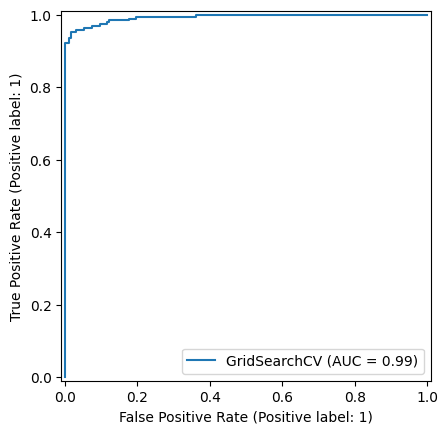

In [ ]:
RocCurveDisplay.from_estimator(estimator=gs_rf,
                               X=X_test,
                               y=y_test);

In [ ]:
print(confusion_matrix(y_test, y_preds))

[[179   9]
 [  8 182]]


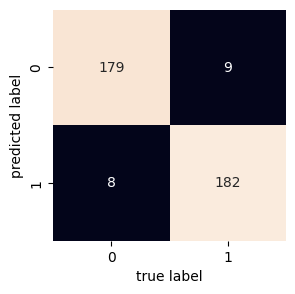

In [ ]:
def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     fmt='d',
                     cbar=False)
    plt.xlabel("true label")
    plt.ylabel("predicted label")

plot_conf_mat(y_test, y_preds)

17 misclassifications out of 378 samples (which is great tbh)
         
and only 9 of these 378 (were told they're healthy instead of sick)

In [ ]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       188
           1       0.95      0.96      0.96       190

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378



In [ ]:
cv_acc = cross_val_score(rs_rf,
                         X,
                         y,
                         cv=2,
                         scoring="accuracy")
cv_acc

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


array([0.99576271, 0.77224576])

In [ ]:
cv_acc = np.mean(cv_acc)
cv_acc

np.float64(0.8840042372881356)

Cross-validated precision score

In [ ]:
cv_precision = np.mean(cross_val_score(rs_rf,
                                       X,
                                       y,
                                       cv=2,
                                       scoring="precision"))
cv_precision

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


np.float64(0.8548634693213006)

Cross-validated recall score

In [ ]:
cv_recall = np.mean(cross_val_score(rs_rf,
                                    X,
                                    y,
                                    cv=2,
                                    scoring="recall"))
cv_recall

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


np.float64(0.8668451842167019)

Cross-validated F1 score

In [ ]:
cv_f1 = np.mean(cross_val_score(rs_rf,
                                X,
                                y,
                                cv=2,
                                scoring="f1"))
cv_f1

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


np.float64(0.8736585512654609)

saving the trained model

In [ ]:
import pickle
filename='trained_model.sav'
pickle.dump(rs_rf,open(filename,'wb'))

loading the saved model

In [ ]:
loaded_model=pickle.load(open('trained_model.sav','rb'))